In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded!")

Libraries loaded!


In [30]:
df = pd.read_csv(r"C:\Users\user\Desktop\DA\project\Marketing AB testing\marketing_AB.csv")

In [31]:
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [32]:
df.tail()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
588096,588096,1278437,ad,False,1,Tuesday,23
588097,588097,1327975,ad,False,1,Tuesday,23
588098,588098,1038442,ad,False,3,Tuesday,23
588099,588099,1496395,ad,False,1,Tuesday,23
588100,588100,1237779,ad,False,1,Tuesday,23


In [33]:
df.sample()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
527115,527115,1313676,ad,False,17,Friday,15


In [34]:
df.shape

(588101, 7)

In [35]:
df.columns

Index(['Unnamed: 0', 'user id', 'test group', 'converted', 'total ads',
       'most ads day', 'most ads hour'],
      dtype='object')

In [36]:
df=df.drop("Unnamed: 0",axis=1)

In [37]:
df.columns = ['user_id', 'test_group', 'converted',
              'total_ads', 'most_ads_day', 'most_ads_hour']

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   user_id        588101 non-null  int64 
 1   test_group     588101 non-null  object
 2   converted      588101 non-null  bool  
 3   total_ads      588101 non-null  int64 
 4   most_ads_day   588101 non-null  object
 5   most_ads_hour  588101 non-null  int64 
dtypes: bool(1), int64(3), object(2)
memory usage: 23.0+ MB


In [39]:
df.describe()

,user_id,total_ads,most_ads_hour
count,5.881010e+05,588101.000000,588101.000000
mean,1.310692e+06,24.820876,14.469061
std,2.022260e+05,43.715181,4.834634
min,9.000000e+05,1.000000,0.000000
25%,1.143190e+06,4.000000,11.000000
50%,1.313725e+06,13.000000,14.000000
75%,1.484088e+06,27.000000,18.000000
max,1.654483e+06,2065.000000,23.000000


In [40]:
df.isnull().sum()

user_id          0
test_group       0
converted        0
total_ads        0
most_ads_day     0
most_ads_hour    0
dtype: int64

In [41]:
duplicates=df.duplicated().sum()
print(duplicates)

0


In [42]:
print(df["test_group"].value_counts())
print(df["converted"].value_counts())
print(df['most_ads_day'].value_counts())

test_group
ad     564577
psa     23524
Name: count, dtype: int64
converted
False    573258
True      14843
Name: count, dtype: int64
most_ads_day
Friday       92608
Monday       87073
Sunday       85391
Thursday     82982
Saturday     81660
Wednesday    80908
Tuesday      77479
Name: count, dtype: int64


In [43]:
df['converted'] = df['converted'].astype(int)
print(df['converted'].value_counts())

converted
0    573258
1     14843
Name: count, dtype: int64


In [44]:
df.to_csv('cleaned_marketing_ab.csv', index=False)

In [45]:
conversion = df.groupby('test_group').agg(
    total_users=('converted', 'count'),
    conversions=('converted', 'sum'),
    conversion_rate=('converted', 'mean')
)
conversion['conversion_rate_pct'] = (conversion['conversion_rate'] * 100).round(2)

print("Conversion Rate by Group:")
print(conversion)

Conversion Rate by Group:
            total_users  conversions  conversion_rate  conversion_rate_pct
test_group                                                                
ad               564577        14423         0.025547                 2.55
psa               23524          420         0.017854                 1.79


In [46]:
ad_group  = df[df['test_group'] == 'ad']['converted']
psa_group = df[df['test_group'] == 'psa']['converted']

p1 = ad_group.mean()
p2 = psa_group.mean()
n1 = len(ad_group)
n2 = len(psa_group)

p_pool = (ad_group.sum() + psa_group.sum()) / (n1 + n2)

se = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))

z_score = (p1 - p2) / se

print(f"Ad conversion rate:   {p1*100:.2f}%")
print(f"PSA conversion rate:  {p2*100:.2f}%")
print(f"Z-score:              {z_score:.4f}")
print()
if abs(z_score) > 1.96:
    print("Result: SIGNIFICANT — ads worked")
else:
    print("Result: NOT significant — could be random")

Ad conversion rate:   2.55%
PSA conversion rate:  1.79%
Z-score:              7.3701

Result: SIGNIFICANT — ads worked


In [47]:
# Difference between groups
diff = (p1 - p2) * 100

# How much better ads performed vs PSA
lift = ((p1 - p2) / p2 * 100).round(2)

# Confidence interval
se_diff = np.sqrt((p1*(1-p1)/n1) + (p2*(1-p2)/n2))
ci_lower = (diff/100 - 1.96 * se_diff) * 100
ci_upper = (diff/100 + 1.96 * se_diff) * 100

print(f"Ads performed {lift}% better than PSA")
print(f"We are 95% confident the true improvement")
print(f"is between {ci_lower:.2f}% and {ci_upper:.2f}%")

Ads performed 43.09% better than PSA
We are 95% confident the true improvement
is between 0.60% and 0.94%


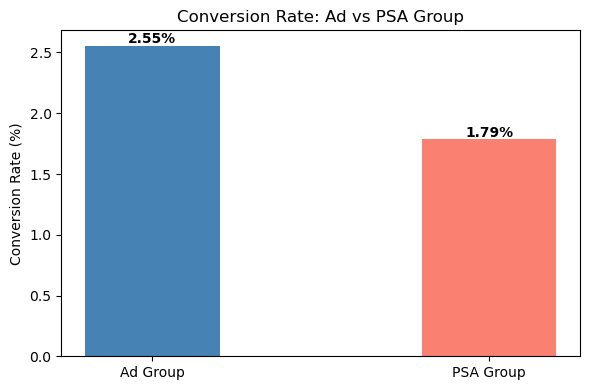

In [48]:
plt.figure(figsize=(6, 4))
plt.bar(['Ad Group', 'PSA Group'],
        [p1*100, p2*100],
        color=['steelblue', 'salmon'], width=0.4)
plt.title('Conversion Rate: Ad vs PSA Group')
plt.ylabel('Conversion Rate (%)')
for i, v in enumerate([p1*100, p2*100]):
    plt.text(i, v + 0.02, f'{v:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_conversion.png', dpi=150)
plt.show()

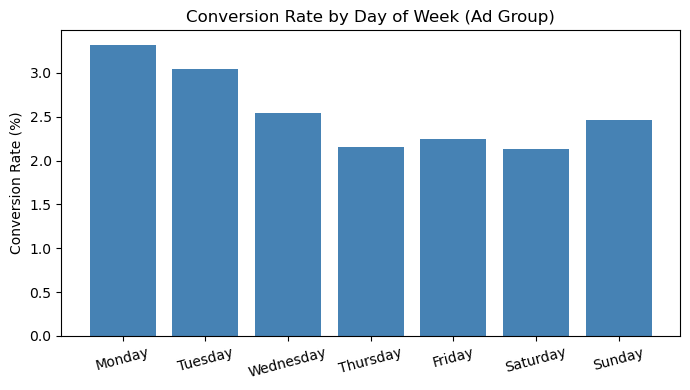

In [49]:
day_order = ['Monday', 'Tuesday', 'Wednesday',
             'Thursday', 'Friday', 'Saturday', 'Sunday']

day_conv = df[df['test_group'] == 'ad'].groupby(
    'most_ads_day')['converted'].mean().mul(100).round(2)
day_conv = day_conv.reindex(day_order)

plt.figure(figsize=(7, 4))
plt.bar(day_conv.index, day_conv.values, color='steelblue')
plt.title('Conversion Rate by Day of Week (Ad Group)')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('chart2_day.png', dpi=150)
plt.show()

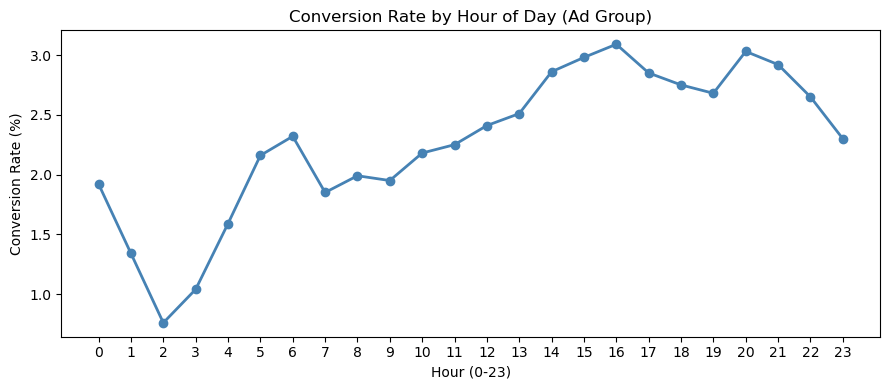

In [50]:
hour_conv = df[df['test_group'] == 'ad'].groupby(
    'most_ads_hour')['converted'].mean().mul(100).round(2)

plt.figure(figsize=(9, 4))
plt.plot(hour_conv.index, hour_conv.values,
         marker='o', color='steelblue', linewidth=2)
plt.title('Conversion Rate by Hour of Day (Ad Group)')
plt.xlabel('Hour (0-23)')
plt.ylabel('Conversion Rate (%)')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig('chart3_hour.png', dpi=150)
plt.show()

In [51]:
print("=" * 45)
print("BUSINESS SUMMARY")
print("=" * 45)
print(f"Total users:           {len(df):,}")
print(f"Ad group:              {n1:,} users")
print(f"PSA group:             {n2:,} users")
print()
print(f"Ad conversion rate:    {p1*100:.2f}%")
print(f"PSA conversion rate:   {p2*100:.2f}%")
print(f"Lift from ads:         {lift}%")
print(f"Z-score:               {z_score:.4f}")
print(f"95% CI:                ({ci_lower:.2f}%, {ci_upper:.2f}%)")
print()
if abs(z_score) > 1.96:
    print("RESULT: Ads are working — statistically proven")
    print("RECOMMENDATION: Continue running ads")
    print("Best day:   Monday (3.32% conversion)")
    print("Best hours: 2pm - 8pm")
else:
    print("RESULT: Ads not proven to work")
    print("RECOMMENDATION: Review ad strategy")
print("=" * 45)

BUSINESS SUMMARY
Total users:           588,101
Ad group:              564,577 users
PSA group:             23,524 users

Ad conversion rate:    2.55%
PSA conversion rate:   1.79%
Lift from ads:         43.09%
Z-score:               7.3701
95% CI:                (0.60%, 0.94%)

RESULT: Ads are working — statistically proven
RECOMMENDATION: Continue running ads
Best day:   Monday (3.32% conversion)
Best hours: 2pm - 8pm
